In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ruchikakumbhar/zomato-dataset/Zomato-data-.csv")

df.head()




,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [7]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [8]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset size after cleaning
print("Dataset Shape:", df.shape)

Dataset Shape: (148, 7)


In [10]:
category = df["listed_in(type)"].value_counts()

print(category)

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


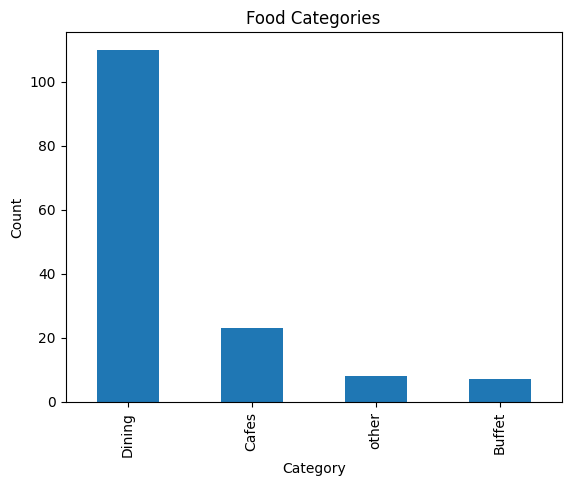

In [11]:
import matplotlib.pyplot as plt

category = df["listed_in(type)"].value_counts()

category.plot(kind="bar")

plt.title("Food Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [15]:
top_votes = df.sort_values(by="votes", ascending=False)

top_votes.head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,Yes,No,4.4/5,4884,750,other
86,Meghana Foods,Yes,No,4.4/5,4401,600,Dining
7,Onesta,Yes,Yes,4.6/5,2556,600,Cafes
44,Onesta,Yes,Yes,4.6/5,2556,600,other
65,Kabab Magic,Yes,No,4.1/5,1720,400,Dining
37,Szechuan Dragon,Yes,No,4.2/5,1647,600,Dining
54,Roving Feast,No,No,4.0/5,1047,450,Dining
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
14,San Churro Cafe,Yes,No,3.8/5,918,800,Cafes
67,Gustoes Beer House,No,No,4.1/5,868,700,Dining


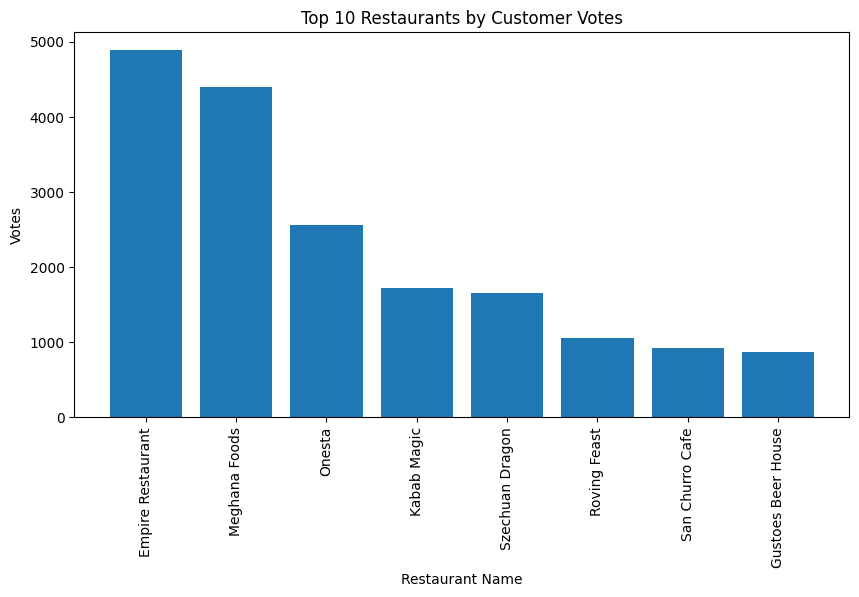

In [16]:
top10 = df.sort_values(by="votes", ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["name"], top10["votes"])

plt.title("Top 10 Restaurants by Customer Votes")
plt.xlabel("Restaurant Name")
plt.ylabel("Votes")

plt.xticks(rotation=90)

plt.show()

In [17]:
online = df["online_order"].value_counts()

print(online)

online_order
No     90
Yes    58
Name: count, dtype: int64


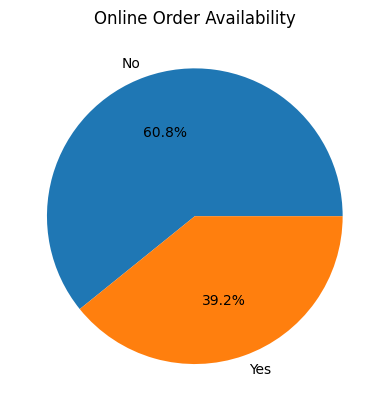

In [18]:
online.plot(kind="pie", autopct="%1.1f%%")

plt.title("Online Order Availability")
plt.ylabel("")

plt.show()

In [20]:
booking = df["book_table"].value_counts()

print(booking)

book_table
No     140
Yes      8
Name: count, dtype: int64


In [22]:
average_cost = df["approx_cost(for two people)"].mean()

print("Average Cost for Two People:", average_cost)

Average Cost for Two People: 418.2432432432432


In [23]:
## Conclusion

print("Conclusion:")
print("The most common food category is Dining.")
print("The restaurant with the highest customer votes is Empire Restaurant.")
print("Most restaurants provide no online ordering.")
print("Only a few restaurants provide table booking.")
print("The average cost for two people is ₹418.243.")
print("Overall, this analysis helps understand customer preferences and restaurant business trends.")

Conclusion:
The most common food category is Dining.
The restaurant with the highest customer votes is Empire Restaurant.
Most restaurants provide no online ordering.
Only a few restaurants provide table booking.
The average cost for two people is ₹418.243.
Overall, this analysis helps understand customer preferences and restaurant business trends.
